# Maplotlib Introduction - InstructorCopy

## Matplotlib programming styles?

Matplotlib supports two complementary programming styles: the **pyplot state-machine interface** and the **object-oriented (OO) interface**.    
The pyplot style (via `matplotlib.pyplot` and functions like `plt.plot`, `plt.title`) operates on an implicit “current” figure and axes, much like MATLAB. It’s great for quick, interactive work—especially in notebooks—because you can create and adjust plots with short, imperative commands without explicitly managing objects. The trade-off is that it relies on global state: functions act on whatever figure/axes are currently active, which can make complex scripts harder to read and reason about.
The object-oriented style, by contrast, is explicit: you create Figure and Axes objects (e.g., with `fig`, `ax = plt.subplots()`), and then call methods on those objects (`ax.plot(...)`, `ax.set_title(...)`). This approach scales better to multi-axes layouts, complex customization, and reusable, testable code because each plot element is a first-class object you control directly.

In practice, both styles are often mixed for quick experiments, while the OO interface is generally recommended for production scripts, libraries, and applications.

1. **State-Based Interface (pyplot)**

 - Implicit and automatic - tracks the "current" figure and axes
 - MATLAB-style - designed to mimic MATLAB syntax
 - Uses plt.plot(), plt.xlabel(), plt.title(), etc.
 - Good for: Quick exploration, simple one-off plots
 - **Problem**: You never explicitly say which figure/axes you're working with

2. **Object-Oriented Interface**

- Explicit and clear - you reference figure and axes objects directly
- Pythonic approach - more professional and maintainable
- Uses ax.plot(), ax.set_xlabel(), ax.set_title(), etc.
- Good for: Complex layouts, multiple figures, reusable code
- **Advantage**: Always crystal clear what you're modifying
<br> 
</br>
<center>
    
|**Main Differences Table**|||
|:-------------------------|---|----|
|Aspect |State-Based (pyplot)|Object-Oriented|
|Syntax|plt.plot()|ax.plot()|
|State| Implicitly tracks "current" figure| You control objects explicitly|
|Clarity|"Which figure am I on?"|Always explicit|
|Multiple plots|Confusing, error-prone|Clear and maintainable|
|Recommended|Quick scripts only|Production code|   
</center>

Here are two examples comparing both types of styles

In [1]:
import numpy as np
import matplotlib.pyplot as plt

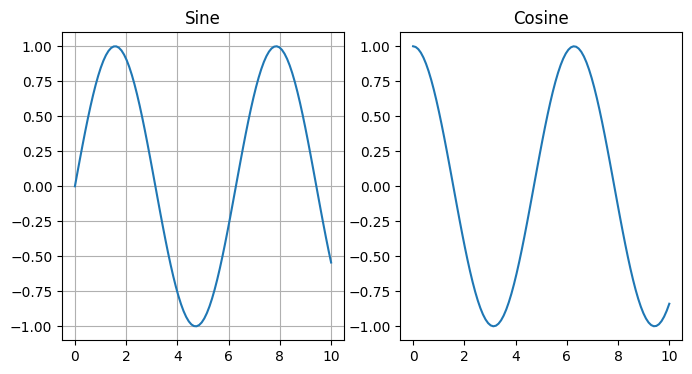

In [2]:
x = np.linspace(0, 10, 100)

# STATE-BASED - Confusing with multiple plots
plt.figure(figsize=(8, 4))

# First subplot
plt.subplot(1, 2, 1)  # Make first subplot "current"
plt.plot(x, np.sin(x))
plt.title('Sine')

# Second subplot
plt.subplot(1, 2, 2)  # Make second subplot "current"
plt.plot(x, np.cos(x))
plt.title('Cosine')

# Want to modify first plot again?
plt.subplot(1, 2, 1)  # Must re-specify which one!
plt.grid(True)
plt.show()

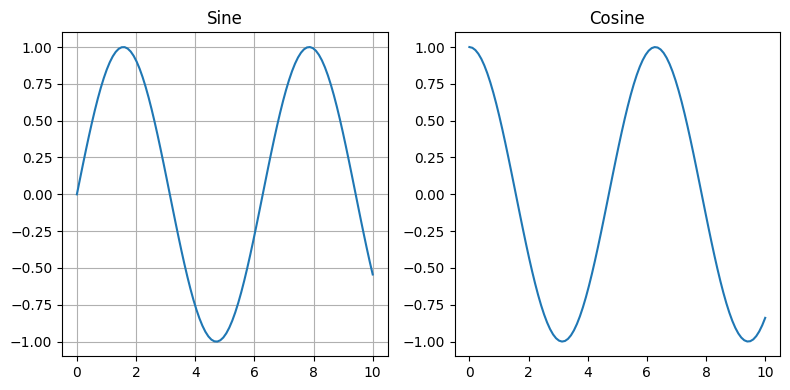

In [19]:
# OBJECT-ORIENTED - Always clear
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# first subplot
axes[0].plot(x, np.sin(x))
axes[0].set_title('Sine')

# Second subplot 
axes[1].plot(x, np.cos(x))
axes[1].set_title('Cosine')

# Go back to first plot - no problem!
axes[0].grid(True)  # Crystal clear which plot we're modifying

plt.tight_layout()
plt.show()

## Figure

Matplotlib has a hierarchical structure. Understanding this hierarchy is crucial for working effectively with the library.. A **Figure** is the top-level container in Matplotlib. Think of it as:
- The entire window or canvas
- A blank piece of paper
- The outermost container that holds everything

In [3]:
# Create just a Figure
fig = plt.figure(figsize=(4,3)) # width, height
plt.show()

<Figure size 400x300 with 0 Axes>

**Key observations:**
- Default figure size is (6.4, 4.8) inches
- Default DPI is 100
- The figure starts empty with no axes
- You see a blank window when displayed

In [4]:
# size of the figure in inches. Default (6.4, 4.8) 
fig.get_size_inches()

array([4., 3.])

**Understanding figsize:**
- `figsize=(width, height)` is in inches
- Default is (6.4, 4.8)
- Common sizes:
  - Single column journal figure: (3.5, 2.5)
  - Double column journal figure: (7, 5)
  - Presentation slide: (10, 7.5)
  - Poster: (16, 12)

In [ ]:
# Dots Per Inch (dpi). Default 100
fig.dpi

100.0

**Understanding DPI:**
- DPI determines the resolution (sharpness)
- Physical size (inches) × DPI = pixel dimensions
- Common DPI values:
  - 72-100: Screen display
  - 150-200: Good quality prints
  - 300: Publication quality
  - 600: High-end printing
- Higher DPI = larger file size

```{important} note
Notice that the figure size is given in pixels or dots and it the product of:
$$
Size \; of \; Figure \; \lparen inches \rparen \quad \cdot \quad Dots\; per\; inch \;(dpi)
$$
```

**Key properties of a Figure:**
- Has a size (in inches)
- Has a DPI (dots per inch) for resolution
- Can contain zero, one, or multiple Axes
- Is mostly a container - doesn't display data directly

## Axes

An **Axes** is the actual plotting area where your data is displayed. Think of it as:
- A rectangular region within the Figure
- Where your data visualization lives
- Contains spines, ticks, labels, and the actual plot elements

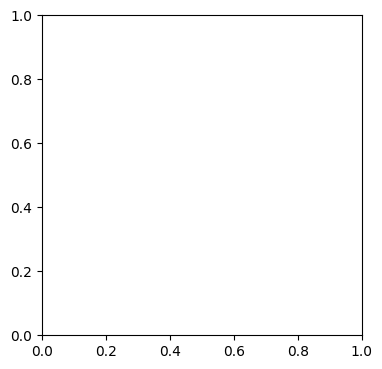

In [5]:
# Create a Figure and add an Axes
fig = plt.figure(figsize=(4, 4))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])  # [left, bottom, width, height] these are the scaling of the axes object
plt.show()

In [6]:
# How many axes does this figure have?
len(fig.axes)

1

In [7]:
# Is this figure associated with this axes?
ax.figure is fig

True

**Key properties of an Axes:**
- Lives inside a Figure
- Has a position within the Figure (in Figure coordinates: 0 to 1)
- Contains spines (the four borders)
- Contains two Axis objects (XAxis and YAxis) - note the singular "Axis"!
- Contains all your plot elements (lines, patches, text, etc.)
- This is where you actually plot your data

## The Relationship: Figure → Axes → Axis

Figure's axes: [<Axes: >]
Number of axes: 1

Axes' x-axis: XAxis(40.0,40.0)
Axes' y-axis: YAxis(40.0,40.0)
Type of xaxis: <class 'matplotlib.axis.XAxis'>

Axes' spines: <matplotlib.spines.Spines object at 0x10eea7100>
Spine names: ['left', 'right', 'bottom', 'top']


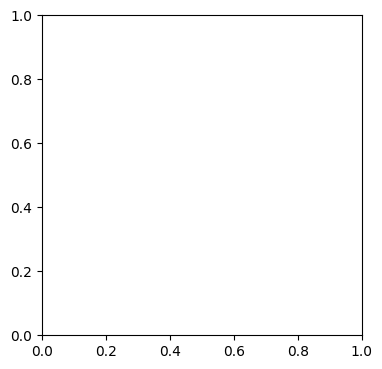

In [8]:
# Let's explore the hierarchy
fig = plt.figure(figsize=(4, 4))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])

# The Figure contains Axes
print("Figure's axes:", fig.axes)
print("Number of axes:", len(fig.axes))

# Each Axes contains two Axis objects
print("\nAxes' x-axis:", ax.xaxis)
print("Axes' y-axis:", ax.yaxis)
print("Type of xaxis:", type(ax.xaxis))

# Each Axes also contains spines
print("\nAxes' spines:", ax.spines)
print("Spine names:", list(ax.spines.keys()))

plt.show()

## Terminology Clarification: *Figure* .vs. *Axes* .vs. *Axis*

This is a common source of confusion:

| Term | Plural | What it is |
|------|--------|------------|
| *Figure* | Figures | The entire canvas/window |
| *Axes* | Axes | A plotting area (**already plural!**) |
| *Axis*| Axes | A single axis (x or y) within an Axes |

## More on Figures

In this part, we'll dive deep into the Figure object - the top-level container for all plot elements. We'll explore different ways to create figures, configure their properties, and understand how they serve as the foundation for your visualizations.

### Figure Background and Facecolor

The figure has a background that you can customize. This is separate from the axes facecolor.

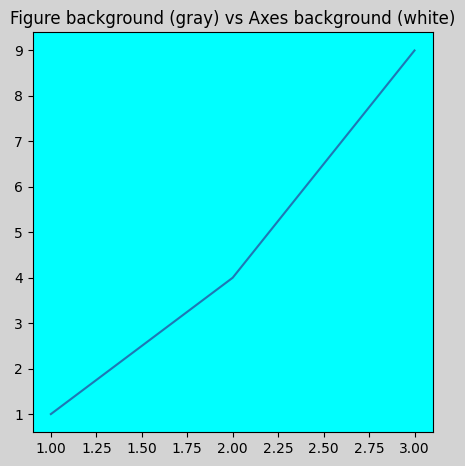

In [11]:
# Create a figure with a colored background
fig = plt.figure(figsize=(4, 4), facecolor='lightgray')

# Add an axes to see the difference between figure and axes background
ax = fig.add_axes([0.1, 0.1, 1.0, 1.0])#the second two numbers determine how for out it goes
#the first two ^^ seem to have no visual effect 
ax.set_facecolor('cyan')
ax.plot([1, 2, 3], [1, 4, 9])
ax.set_title('Figure background (gray) vs Axes background (white)')

plt.show()

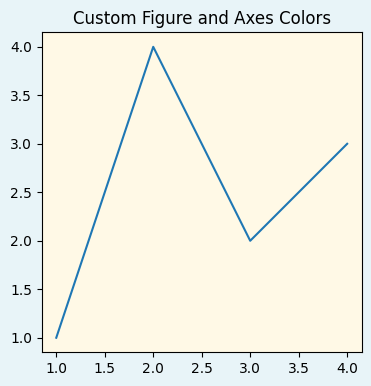

In [12]:
# You can also modify facecolor after creation
fig = plt.figure(figsize=(4, 4))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])

# Change the figure facecolor
fig.patch.set_facecolor('#E8F4F8')  # Light blue using hex color

# Change the axes facecolor
ax.set_facecolor('#FFF9E6')  # Light yellow

ax.plot([1, 2, 3, 4], [1, 4, 2, 3])
ax.set_title('Custom Figure and Axes Colors')

plt.show()

**Color specifications:**
- Named colors: `'white'`, `'lightgray'`, `'red'`, etc.
- Hex colors: `'#RRGGBB'` (e.g., `'#E8F4F8'`). See [Codes of Color](https://codesofcolors.com/)
- RGB tuples: `(r, g, b)` where values are 0-1 (e.g., `(0.9, 0.9, 1.0)`)
- RGBA tuples: `(r, g, b, alpha)` for transparency

### Figure Numbers and References

Matplotlib can manage multiple figures simultaneously. Each figure gets a unique number.

In [13]:
# Create multiple figures
fig1 = plt.figure()
fig2 = plt.figure()
fig3 = plt.figure()

print("Figure 1 number:", fig1.number)
print("Figure 2 number:", fig2.number)
print("Figure 3 number:", fig3.number)

# You can also create a figure with a specific number
fig_specific = plt.figure(num=10)
print("Specific figure number:", fig_specific.number)

# Get a list of all figure numbers
print("All figure numbers:", plt.get_fignums())

plt.close('all')

Figure 1 number: 1
Figure 2 number: 2
Figure 3 number: 3
Specific figure number: 10
All figure numbers: [1, 2, 3, 10]


**Managing multiple figures:**
- Each figure gets an auto-incremented number
- You can specify a number with `num=` parameter
- Use `plt.figure(num=1)` to retrieve an existing figure
- Use `plt.close(fig)` to close a specific figure
- Use `plt.close('all')` to close all figures

### Figure Properties: A Complete Example

Let's create a figure with multiple customizations to see how properties work together.

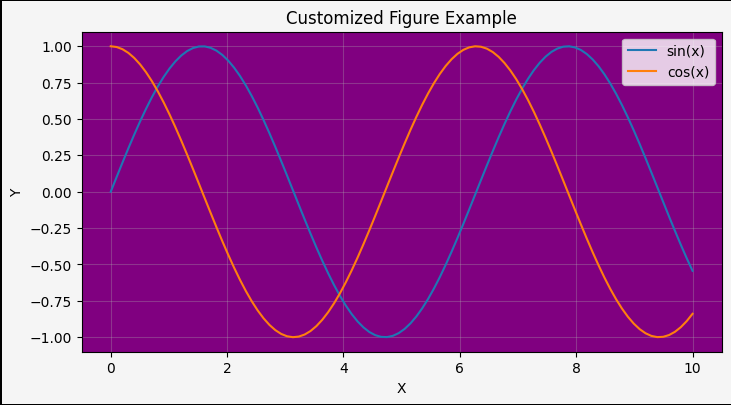

In [19]:
# Create a fully customized figure
fig = plt.figure(
    num=100,                   # Specific figure number
    figsize=(8, 4),            # Size in inches
    dpi=100,                   # Resolution
    facecolor='#F5F5F5',       # Light gray background
    edgecolor='black',         # Border color
    linewidth=2,               # Border width
    frameon=True               # Show the frame
)

# Add an axes and plot some data
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
x = np.linspace(0, 10, 100)
ax.plot(x, np.sin(x), label='sin(x)')
ax.plot(x, np.cos(x), label='cos(x)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Customized Figure Example')
ax.legend() # adds a legend
ax.grid(True, alpha=0.3)
ax.set_facecolor('purple')

plt.show()

## Saving Figures

Once you've created a figure, you'll often want to save it. The Figure object has a `savefig()` method.

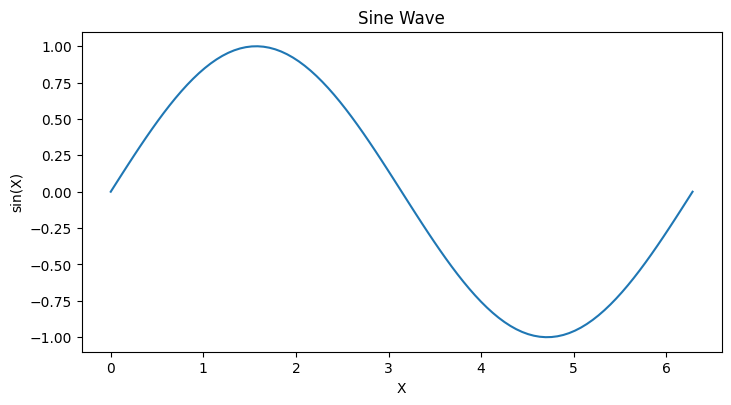

In [16]:
# Create a simple figure
fig = plt.figure(figsize=(8, 4))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
x = np.linspace(0, 2*np.pi, 100)
ax.plot(x, np.sin(x))
ax.set_xlabel('X')
ax.set_ylabel('sin(X)')
ax.set_title('Sine Wave')
plt.show()

In [5]:
# Save in different formats
fig.savefig('sine_wave.png', dpi=150, bbox_inches='tight')
fig.savefig('sine_wave.pdf', bbox_inches='tight')
fig.savefig('sine_wave.svg', bbox_inches='tight')

**savefig() key parameters:**
- `fname`: Filename (extension determines format)
- `dpi`: Resolution (default: figure's dpi)
- `bbox_inches='tight'`: Trim whitespace
- `facecolor`: Background color (default: figure's facecolor)
- `transparent=True`: Transparent background (PNG)
- `format`: Explicitly specify format (png, pdf, svg, jpg, etc.)

**Common formats:**
- PNG: Raster, good for web and presentations
- PDF: Vector, perfect for publications
- SVG: Vector, editable in Illustrator/Inkscape
- JPG: Raster, smaller file size but lossy compression

## 1. Scatter Plot - `scatter()`

In [22]:
# Set random seed for reproducibility
np.random.seed(42)

# Optional: Set style
plt.style.use('default')

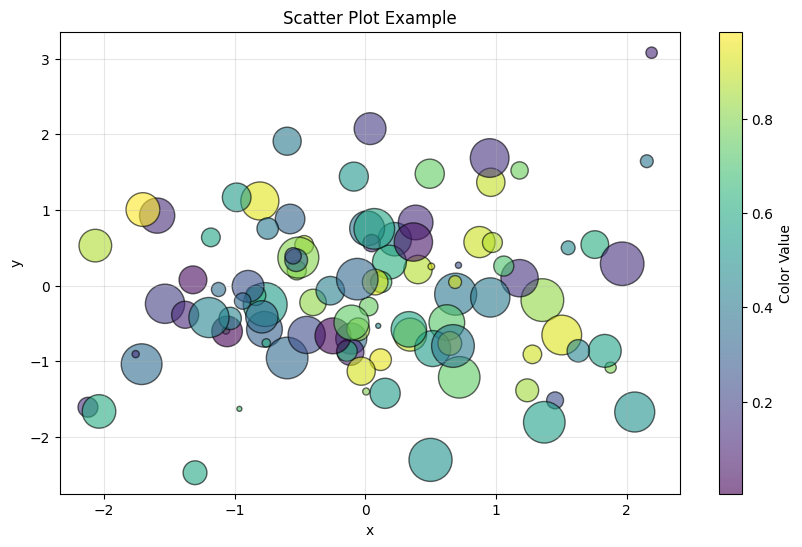

In [24]:
n = 100
x = np.random.randn(n)
y = np.random.randn(n)
colors = np.random.rand(n)
sizes = 1000 * np.random.rand(n)

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(x, y, s=sizes, c=colors, cmap='viridis', 
                     alpha=0.6, edgecolors='black', linewidths=1)
fig.colorbar(scatter, ax=ax, label='Color Value')
ax.set_title('Scatter Plot Example')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.grid(True, alpha=0.3)
plt.show()

**Main ScatterPlot Parameters:**
- `x`, `y` - Data arrays (required)
- `s` - Marker size (default: `None` → 36 points², range: any positive value or array)
- `c` - Marker color (default: from color cycle, can be single color or array for color mapping)
- `marker` - Marker style (default: `'o'`, options: `'o'`, `'s'`, `'^'`, `'*'`, `'D'`, etc.)
- `cmap` - Colormap for color mapping (default: `None`, e.g., `'viridis'`, `'plasma'`)
- `alpha` - Transparency (default: `1.0`, range: 0.0-1.0)
- `edgecolors` - Edge colors (default: `'face'`, options: color or `'none'`)
- `linewidths` - Edge line width (default: `1.0`, range: any positive float)
- `vmin`, `vmax` - Color scale limits (default: `None`)

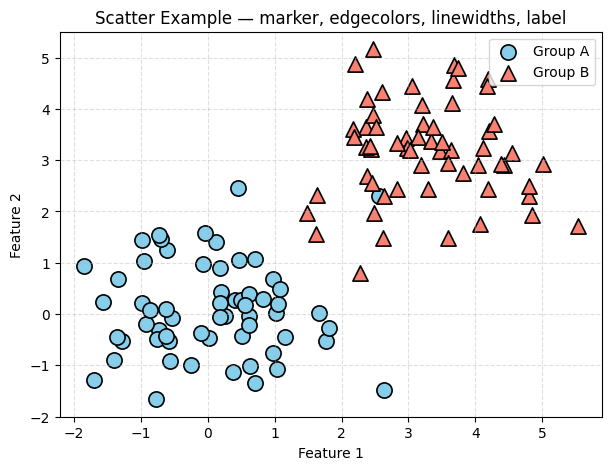

In [25]:
fig, ax = plt.subplots(figsize=(7, 5))

x1, y1 = np.random.randn(60), np.random.randn(60)
x2, y2 = np.random.randn(60) + 3, np.random.randn(60) + 3

ax.scatter(
    x1, y1,
    marker="o",                 # circle
    c="skyblue",
    edgecolors="black",         # outline color
    linewidths=1.2,             # outline thickness
    s=120,
    label="Group A"
)

ax.scatter(
    x2, y2,
    marker="^",                 # triangle
    c="salmon",
    edgecolors="black",
    linewidths=1.2,
    s=120,
    label="Group B"
)

ax.set_title("Scatter Example — marker, edgecolors, linewidths, label")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)

plt.show()


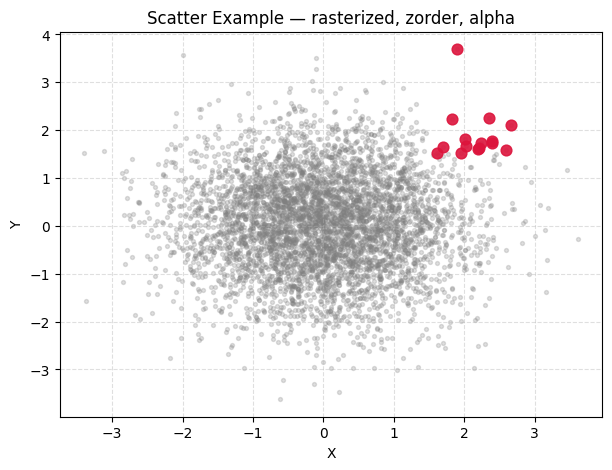

In [32]:
fig, ax = plt.subplots(figsize=(7, 5))

# Simulate a large dataset
x = np.random.randn(5000)
y = np.random.randn(5000)

# Background layer: faint points
ax.scatter(
    x, y,
    s=8,
    c="gray",
    alpha=0.25,            # very transparent
    rasterized=True,       # optimize rendering for large datasets
    zorder=1               # draw underneath
)

# Foreground layer: highlighted subset
mask = (x > 1.5) & (y > 1.5)
ax.scatter(
    x[mask], y[mask],
    s=60,
    c="crimson",
    alpha=0.9,
    zorder=3               # draw above background
)

ax.set_title("Scatter Example — rasterized, zorder, alpha")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.grid(True, linestyle="--", alpha=0.4)

plt.show()


# Exercises

1. Create a figure with two axes.
   1. The figure should have size of 4" high and 8" wide.
   2. Plot a *sine* on the left and cosine on the *right*
   3. Each figure should have a title

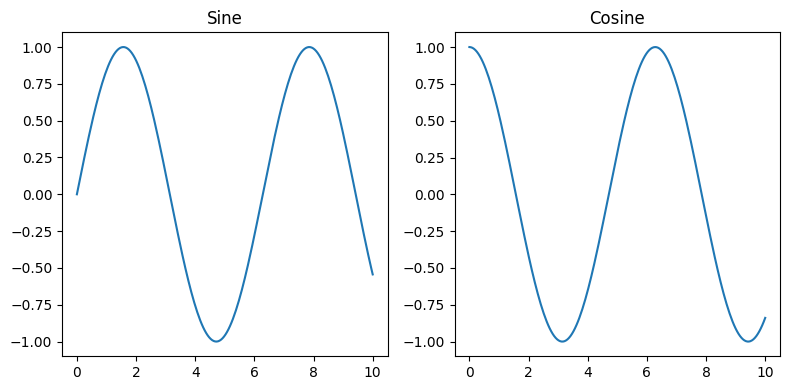

In [26]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 10, 200)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].plot(x, np.sin(x))
axes[0].set_title("Sine")

axes[1].plot(x, np.cos(x))
axes[1].set_title("Cosine")

plt.tight_layout()
plt.show()


2. Create a figure with a light gray figure background and an Axes with a light yellow background.
Plot any simple line on the Axes.

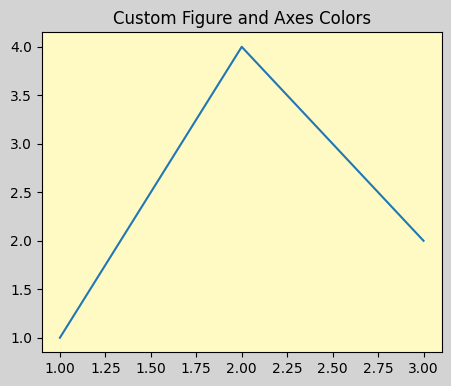

In [34]:
fig = plt.figure(figsize=(5, 4), facecolor="lightgray")
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])

ax.set_facecolor("#FFF9C4")  # light yellow
ax.plot([1, 2, 3], [1, 4, 2])

ax.set_title("Custom Figure and Axes Colors")
plt.show()


3. Generate 200 random points and create a scatter plot where:
    - marker sizes vary randomly from 20 to 200
    - colors vary randombly and use a colormap ('inferno')
    - transparency is set constant to 0.6

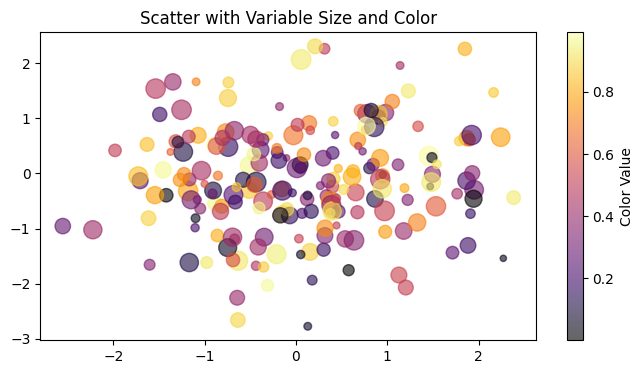

In [36]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
x = np.random.randn(200)
y = np.random.randn(200)
sizes = np.random.uniform(20, 200, 200)
colors = np.random.rand(200)

fig, ax = plt.subplots(figsize=(8, 4))

sc = ax.scatter(x, y, s=sizes, c=colors, cmap="inferno", alpha=0.6)
fig.colorbar(sc, ax=ax, label="Color Value")

ax.set_title("Scatter with Variable Size and Color")
plt.show()


4. Create a scatter plot with 300 gray background points and highlight points where x > 0.5 and y > 1 in red.
Ensure the red points appear on top using zorder and have a transparency of 0.7

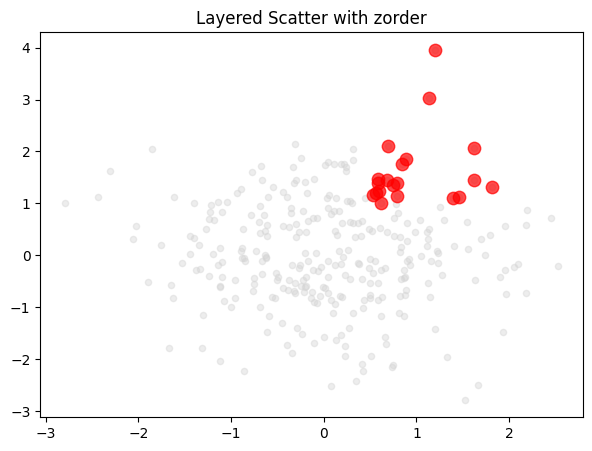

In [39]:
np.random.seed(1)
x = np.random.randn(300)
y = np.random.randn(300)

fig, ax = plt.subplots(figsize=(7, 5))

# background layer
ax.scatter(x, y, s=20, c="lightgray", alpha=0.4, zorder=1)

# highlighted layer
mask = (x > 0.5) & (y > 1)
ax.scatter(x[mask], y[mask], s=80, c="red", zorder=3,alpha= 0.7)

ax.set_title("Layered Scatter with zorder")
plt.show()
